In [1]:
import cobra
import pickle
import pycomo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pycomo.configure_logger(level="error")

2026-09-16 12:13:05,407 - PyCoMo - INFO - Logger initialized.


In [2]:
with open("../run_metadata_heme.pkl", "rb") as f:
    run_metadata = pickle.load(f)

FIXED_UPTAKE = run_metadata["fixed_uptake"]

In [3]:
common_uptakes = ['so4', 'pi', 'mg2', 'k', 'ca2', 'h', 'h2', 'h2o']

patterns = {"Rhodoferax_heme": {
            "mEmC_1": {"uptakes": ["nh4", "fe2", "fum", "o2"],
                        "secretion": ["mal_L",  "co2"]},
            # "mEmC_3": {"uptakes": ["nh4", "fe2", "fum", "o2"],
            #             "secretion": ["mal_L",  "co2"]},
    
            # "mEmC_2": {"uptakes": ["nh4", "fe2", "cit", "o2"],
            #         "secretion": ["mal_L",  "co2"]},
            # "mEmC_4": {"uptakes": ["nh4", "fe2", "cit", "o2"],
            #         "secretion": ["mal_L",  "co2"]},
            # "mEmC_5": {"uptakes": ["nh4", "fe2", "mal_L", "o2"],
            #         "secretion": ["co2"]},
            # "mEmC_6": {"uptakes": ["nh4", "fe2", "mal_L", "o2", "co2"],
            #           "secretion": []},
            # "mE_1": {"uptakes": ["nh4", "ac", "fe3", "o2"],
            #         "secretion": ["co2"]},
            # "mU_1": {"uptakes": ["nh4", "ac", "fe3", "o2"],
            #         "secretion": ["co2"]},
},
        "Geobacter": {
            "mEmC_1": {"uptakes": ["nh4", "fe3", "mal_L"],
                      "secretion": ["fe2", "co2", "h2s"]},
            # "mEmC_2": {"uptakes": ["nh4", "fe3", "mal_L"],
            #           "secretion": ["fe2", "co2", "h2s"]},
            # "mEmC_3": {"uptakes": ["n2", "fe3", "mal_L"],
            #           "secretion": ["fe2", "co2", "h2s"]},
            # "mEmC_4": {"uptakes": ["n2", "fe3", "mal_L"],
            #           "secretion": ["fe2", "co2", "h2s"]},
            # "mEmC_5": {"uptakes": ["n2", "fe3", "cit"],
            #           "secretion": ["fe2", "mal_L", "co2", "h2s"]},
            # "mEmC_6": {"uptakes": ["n2", "fe3", "cit"],
            #           "secretion": ["fe2", "mal_L", "co2", "h2s"]},
            # "mE_1": {"uptakes": ["n2", "fe3", "mal_L"],
            #       "secretion": ["fe2", "ac", "co2", "h2s"]},
            # "mU_1": {"uptakes": ["n2", "fe3", "lac_L"],
            #       "secretion": ["fe2", "ac", "co2", "h2s"]},
    }}

crossfed = {"mEmC_1": ["mal_L", "fe2"],
          # "mEmC_2": ["mal_L", "fe2"],
          # "mEmC_3": ["mal_L", "fe2"],
          # "mEmC_4": ["mal_L", "fe2"],
          # "mEmC_5": ["mal_L", "fe2"],
          # "mEmC_6": ["mal_L", "co2",  "fe2"],
          # "mE_1": ["ac"],
          # "mU_1": ["ac"]
           }

main_c_source = {"mEmC_1": {"c_source": "fum", "feeder": "Rhodoferax_heme", 
                            "receiver": "Geobacter", "crossfed": "mal_L"},
                 # "mEmC_2": {"c_source": "cit", "feeder": "Rhodoferax",
                 #            "receiver": "Geobacter", "crossfed": "mal_L"},
                 # "mEmC_3": {"c_source": "fum", "feeder": "Rhodoferax",
                 #            "receiver": "Geobacter", "crossfed": "mal_L"},
                 # "mEmC_4": {"c_source": "cit", "feeder": "Rhodoferax",
                 #            "receiver": "Geobacter", "crossfed": "mal_L"},
                 # "mEmC_5": {"c_source": "cit", "feeder": "Geobacter", 
                 #            "receiver": "Rhodoferax", "crossfed": "mal_L"},
                 # "mEmC_6": {"c_source": "cit", "feeder": "Geobacter",
                 #            "receiver": "Rhodoferax", "crossfed": "mal_L"},
                 # "mE_1":   {"c_source": "mal_L", "feeder": "Geobacter",
                 #            "receiver": "Rhodoferax", "crossfed": "ac"},
                 # "mU_1":   {"c_source": "lac_L", "feeder": "Geobacter",
                 #            "receiver": "Rhodoferax", "crossfed": "ac"}
                }


In [4]:
model_dir = "../models/xml_models_test"
named_models = pycomo.load_named_models_from_dir(model_dir)
single_org_models = []
for modelname, model in named_models.items():
    print(modelname, model.slim_optimize())

    single_org_model = pycomo.SingleOrganismModel(model, modelname)
    single_org_models.append(single_org_model)

Rhodoferax_heme 29.411764705882355
Geobacter 35.65356530827638


In [5]:
def get_medium_for_pattern(pattern, patterns, 
                           c_sources, crossfed, models):
    # basic medium
    medium = {
        'EX_so4_medium': 1000.,
        'EX_pi_medium': 1000.,
        'EX_mg2_medium': 1000.,
        'EX_k_medium': 1000.,
        'EX_ca2_medium': 1000.,
        'EX_h_medium': 1000.,
        'EX_h2_medium': 1000.,
        'EX_h2o_medium': 1000.}

    for modelname in models:
        for component in patterns[modelname][pattern]["uptakes"]:
            max_uptake = 1000.
            if component in c_sources:
                max_uptake = float(FIXED_UPTAKE)
            if component in crossfed[pattern]:
                continue
    
            medium_name = f"EX_{component}_medium"
            medium[medium_name] = max_uptake
    return medium

In [6]:
def implement_dime(pattern, patterns, com_model):
    for rxn in com_model.transfer_reactions:
        for organism in patterns.keys():
            if organism in rxn.id:
                individual_uptakes = patterns[organism][pattern]["uptakes"]
    
                # allow uptakes from medium too
                if any(f"_{met}_" in rxn.id for met in common_uptakes):
                    rxn.lower_bound = -1000
                    rxn.upper_bound = 1000
                    #print(f"{rxn.id} taken up/secreted")
                elif any(f"_{met}_" in rxn.id for met in individual_uptakes):
                    rxn.lower_bound = -1000
                    rxn.upper_bound = 0
                    #print(f"{rxn.id} taken up")
                else:
                    rxn.lower_bound = 0
                    rxn.upper_bound = 1000
                    #print(f"{rxn.id} secreted")


In [7]:
def get_compositions(com_model, mus, organism="Geobacter"):
    mins = []
    maxs = []
    feasible_mus = []

    for mu in mus:
        try:
            comps = com_model.feasible_composition_range(mu)
        except Exception as e:
            print(f"Growth rate {mu} infeasible")
            break
            
        feasible_mus.append(mu)
        geo = comps.loc[comps.reaction_id == f"{organism}_fraction_reaction"]
        mins.append(geo.min_flux.item())
        maxs.append(geo.max_flux.item())

    return feasible_mus, mins, maxs

def plot_compositions(mus, mins, maxs, organism="Geobacter", title=""):
    color = "#00a797" # "#d43689"

    plt.fill_betweenx(mus, mins, maxs, alpha = 0.5, color = color)
    plt.xlabel(f"Fraction of {organism}", size=15)
    plt.ylabel("Growth rate", size=15)
    plt.title(title)
    plt.savefig(f"../figures/{title}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [8]:
community_name = "uranium_community"
com_model_orig = pycomo.CommunityModel(single_org_models, community_name)
com_model_orig.model.solver = "cplex"
com_model_orig.model.tolerance = 1e-9

In [9]:
com_model_orig.max_growth_rate(return_abundances=True, minimal_abundance=0.1)

2026-09-16 12:13:12,550 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:13,781 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:15,669 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:16,956 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:18,807 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:20,062 - PyCoMo - INFO - Logger initialized.


,reaction_id,min_flux,max_flux
0,Rhodoferax_heme_fraction_reaction,0.000000,1.000000
1,Geobacter_fraction_reaction,0.000000,1.000000
2,community_biomass,29.411764,29.411764


LB set on Rhodoferax_heme_TF_fum_Rhodoferax_heme_e_lb
LB set on Geobacter_TF_mal_L_Geobacter_e_lb


2026-09-16 12:13:26,831 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:28,148 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:30,105 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:31,366 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:33,220 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:34,477 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:36,612 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:37,855 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:39,740 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:41,022 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:42,829 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:44,077 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:45,878 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:47,137 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:48,924 - PyCoMo - INFO - Logger initialized.
2026-09-16 12:13:50,180 - PyCoMo - INFO - Logger initialized.
2026-09-

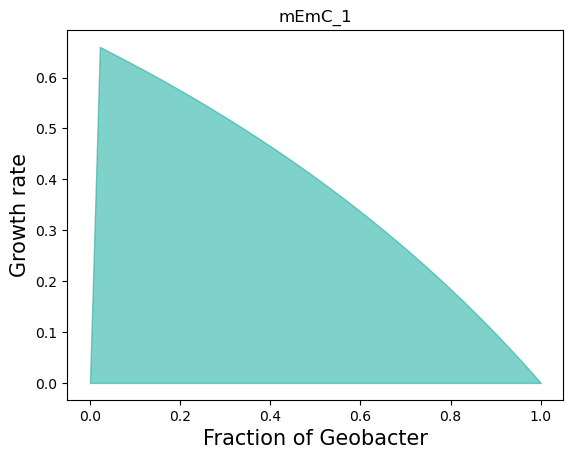

In [10]:
uptake_main = FIXED_UPTAKE/100
results = [] 
flux_results = {}

for pattern in crossfed:
    named_models = pycomo.load_named_models_from_dir(model_dir)
    single_org_models = []
    for modelname, model in named_models.items():
        single_org_model = pycomo.SingleOrganismModel(model, modelname)
        single_org_models.append(single_org_model)

    com_model = pycomo.CommunityModel(single_org_models, community_name)
    com_model.model.solver = "cplex"
    com_model.model.tolerance = 1e-9
    
    feeder = main_c_source[pattern]["feeder"]
    receiver = main_c_source[pattern]["receiver"]
    c_source = main_c_source[pattern]["c_source"]
    crossfed_c_source = main_c_source[pattern]["crossfed"]
    c_sources = [c_source, crossfed_c_source]
    
    medium = get_medium_for_pattern(pattern, patterns, 
                                    c_sources, crossfed, 
                                    named_models.keys())
    com_model.medium = medium
    com_model.apply_medium()

    implement_dime(pattern, patterns, com_model)
    
    # set uptake rate for main carbon source
    bounds_rxn = com_model.model.reactions.get_by_id(f"{feeder}_fraction_reaction")
    for met, stoich in bounds_rxn.metabolites.items():
        if (f"_{c_source}_" in met.id) and ("_lb" in met.id):
            bounds_rxn.add_metabolites({met: uptake_main}, combine=False)
            print(f"LB set on {met.id}")
 
    bounds_rxn2 = com_model.model.reactions.get_by_id(f"{receiver}_fraction_reaction")
    for met, stoich in bounds_rxn2.metabolites.items():
        if (f"_{crossfed_c_source}_" in met.id) and ("_lb" in met.id):
            bounds_rxn2.add_metabolites({met: uptake_main}, combine=False)
            print(f"LB set on {met.id}")
    
    fba = com_model.max_growth_rate(return_abundances=True, minimal_abundance=1e-7)
    max_mu = fba.loc[fba.reaction_id == "community_biomass"].max_flux.item()
    
    tested_mus = np.linspace(0, max_mu, 30)
    mus, mins, maxs = get_compositions(com_model, tested_mus)
    plot_compositions(mus, mins, maxs, title=pattern)

    # collect rows for this pattern
    for mu, lo, hi in zip(mus, mins, maxs):
        results.append({
            "pattern": pattern,
            "mu": mu,
            "min_fraction": lo,
            "max_fraction": hi,
        })

results_df = pd.DataFrame(results)
results_df.to_csv("../results/pycomo_composition_ranges_heme.csv", index=False)

In [11]:
results_df

,pattern,mu,min_fraction,max_fraction
0,mEmC_1,0.000000,0.000000,1.000000
1,mEmC_1,0.022762,0.000773,0.977323
2,mEmC_1,0.045524,0.001545,0.954109
3,mEmC_1,0.068287,0.002316,0.930339
4,mEmC_1,0.091049,0.003086,0.905992
5,mEmC_1,0.113811,0.003855,0.881048
6,mEmC_1,0.136573,0.004622,0.855483
7,mEmC_1,0.159336,0.005388,0.829276
8,mEmC_1,0.182098,0.006153,0.802400
9,mEmC_1,0.204860,0.006917,0.774830
